In [1]:
%pip install statsmodels -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import (
    feature_selection,
    metrics,
    model_selection,
    preprocessing,
)
from statsmodels.tsa.seasonal import seasonal_decompose

### Первичный анализ

In [3]:
coffee_df = pd.read_csv("data/coffee_analysis.csv")

display(coffee_df.head(3))

print(
    f"Всего строк в данных: {coffee_df.shape[0]}\n"
    f"Всего колонок: {coffee_df.shape[1]}"
)

,uid,name,roaster,roast,loc_country,origin_1,origin_2,100g_USD,rating,review_date,desc_1,source_review
0,565e9123c6554a48bd0fb1fdc3cd2227,“Sweety” Espresso Blend,A.R.C.,Medium-Light,Hong Kong,Panama,Ethiopia,14.32,"95,0",November 2017,"Evaluated as espresso. Sweet-toned, deeply ric...",cite
1,813a7c786bdf42d6b14e9b489c4ce108,Ethiopia Shakiso Mormora,Revel Coffee,Medium-Light,United States,Guji Zone,Southern Ethiopia,4.70,"92,0",November 2017,"Crisply sweet, cocoa-toned. Lemon blossom, roa...",cite
2,ba6670beda0447499ca11fae5c98c113,Ethiopia Suke Quto,Roast House,Medium-Light,United States,Guji Zone,Oromia Region,4.19,"92,0",November 2017,"Delicate, sweetly spice-toned. Pink peppercorn...",cite


Всего строк в данных: 1996
Всего колонок: 12


**Вывод:**  
На мой взгляд, для простой линейной модели данных достаточно. Тем более, в первом приближении, мы имеем небольшое количество признаков (без учета последующих преобразований).

### Проверка типов признаков

In [4]:
coffee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   uid            1996 non-null   object 
 1   name           1996 non-null   object 
 2   roaster        1996 non-null   object 
 3   roast          1984 non-null   object 
 4   loc_country    1996 non-null   object 
 5   origin_1       1996 non-null   object 
 6   origin_2       1996 non-null   object 
 7   100g_USD       1988 non-null   float64
 8   rating         1996 non-null   object 
 9   review_date    1996 non-null   object 
 10  desc_1         1996 non-null   object 
 11  source_review  1996 non-null   object 
dtypes: float64(1), object(11)
memory usage: 187.3+ KB


In [5]:
print(
    f"Отстутствующие значения по колонкам: \n{coffee_df.isna().sum()}"
    "\n\n"
    f"Количество дубликатов строк: {coffee_df.duplicated().sum()}"
)

Отстутствующие значения по колонкам: 
uid               0
name              0
roaster           0
roast            12
loc_country       0
origin_1          0
origin_2          0
100g_USD          8
rating            0
review_date       0
desc_1            0
source_review     0
dtype: int64

Количество дубликатов строк: 0


**Вывод:**  
Есть необходимость явно преобразовать многие признаки к подходящим типам, только целевой признак имеет правильный. Пропусков крайне мало, около 1% от всего объема; можно удалить (для target), можно заполнить модой (для признака).

### Исследование статистики числовых признаков

In [6]:
display(coffee_df.describe(include="object"))
display(coffee_df.describe())

,uid,name,roaster,roast,loc_country,origin_1,origin_2,rating,review_date,desc_1,source_review
count,1996,1996,1996,1984,1996,1996,1996,1996,1996,1996,1996
unique,1996,1818,409,5,18,462,253,15,61,1993,1
top,cec117f550f64b2cb4879324743c85f4,Espresso Blend,JBC Coffee Roasters,Medium-Light,United States,Guji Zone,Southern Ethiopia,"93,0",October 2020,"Evaluated as espresso. Blueberry, Nutella, nar...",cite
freq,1,6,150,1419,1265,136,146,576,60,2,1996


,100g_USD
count,1988.000000
mean,9.214437
std,11.481039
min,0.170000
25%,4.930000
50%,5.860000
75%,8.485000
max,132.280000


**Вывод:**  
- Из неинформативных: `uid`, `name` (возможно, нужно исследовать семантику), `source_reviev` (одно значение на все строки)
- Требуют более детального рассмотрения: `review_date` (временной ряд), `desc_1` (семантика, настроение комментария)
- Много категориальных переменных: необходима либо группировка, либо частотное кодирование, либо target-кодирование
- Выбросы: очень даже ожидаемые для финансовых значений, `100g_USD` - длинный правый хвост, редкие события

### Исследуемый период

In [7]:
print(coffee_df["review_date"].unique())

DT_FORMAT = "%d %B %Y"
START_DAY = "01 "

# преобразование из object в datetime
coffee_df["review_date"] = pd.to_datetime(
    START_DAY + coffee_df["review_date"],
    format=DT_FORMAT,
)

first_date = coffee_df["review_date"].min()
last_date = coffee_df["review_date"].max()

print(
    f"\nДанные представлены за период с {first_date.month} месяца {first_date.year} года "
    f"по {last_date.month} месяц {last_date.year} года."
)

['November 2017' 'December 2017' 'January 2018' 'February 2018'
 'March 2018' 'April 2018' 'May 2018' 'June 2018' 'July 2018'
 'August 2018' 'September 2018' 'October 2018' 'November 2018'
 'December 2018' 'February 2019' 'January 2019' 'March 2019' 'April 2019'
 'May 2019' 'June 2019' 'July 2019' 'August 2019' 'September 2019'
 'October 2019' 'November 2019' 'December 2019' 'January 2020'
 'February 2020' 'March 2020' 'April 2020' 'May 2020' 'June 2020'
 'July 2020' 'August 2020' 'September 2020' 'October 2020' 'November 2020'
 'December 2020' 'January 2021' 'February 2021' 'March 2021' 'April 2021'
 'May 2021' 'June 2021' 'July 2021' 'August 2021' 'September 2021'
 'October 2021' 'November 2021' 'December 2021' 'January 2022'
 'February 2022' 'March 2022' 'April 2022' 'May 2022' 'June 2022'
 'July 2022' 'August 2022' 'September 2022' 'October 2022' 'November 2022']

Данные представлены за период с 11 месяца 2017 года по 11 месяц 2022 года.


### Приведение признаков к нужным типам

In [8]:
# преобразование из object в категории
categories = [
    "name", "roaster", "roast", "loc_country",
    "origin_1", "origin_2", "source_review",
]
coffee_df[categories] = coffee_df[categories].astype("category")

# преобразование из object в строки
strings = ["uid", "desc_1"]
coffee_df[strings] = coffee_df[strings].astype("string")

# преобразование из object в число типа float
coffee_df["rating"] = (
    coffee_df["rating"]
    .map(lambda x: x.replace(",", "."))
    .astype("float64")
)

coffee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   uid            1996 non-null   string        
 1   name           1996 non-null   category      
 2   roaster        1996 non-null   category      
 3   roast          1984 non-null   category      
 4   loc_country    1996 non-null   category      
 5   origin_1       1996 non-null   category      
 6   origin_2       1996 non-null   category      
 7   100g_USD       1988 non-null   float64       
 8   rating         1996 non-null   float64       
 9   review_date    1996 non-null   datetime64[ns]
 10  desc_1         1996 non-null   string        
 11  source_review  1996 non-null   category      
dtypes: category(7), datetime64[ns](1), float64(2), string(2)
memory usage: 228.5 KB


### Исследование признака `loc_country`

In [9]:
print(coffee_df["loc_country"].unique(), end="\n\n")
print("Неизвестная страна:", end="\n")
display(coffee_df[coffee_df["loc_country"] == "United States And Floyd"])

['Hong Kong', 'United States', 'Canada', 'Taiwan', 'Hawai'i', ..., 'Peru', 'Honduras', 'China', 'Kenya', 'Malaysia']
Length: 18
Categories (18, object): ['Australia', 'Belgium', 'Canada', 'China', ..., 'Taiwan', 'Uganda', 'United States', 'United States And Floyd']

Неизвестная страна:


,uid,name,roaster,roast,loc_country,origin_1,origin_2,100g_USD,rating,review_date,desc_1,source_review
802,eb2a9c4c3d39472c80404d25124fbec1,All Rise,RND & Red Rooster Coffee Roaster,Medium-Light,United States And Floyd,Ethiopia,Democratic Republic Of The Congo,5.88,94.0,2020-07-01,"High-toned, richly sweet-tart. Pie cherry, dar...",cite


In [10]:
COUNTRY_MAPPER = {
    "Hawai'i": "United States",
    "United States And Floyd": "United States",
    "Hong Kong": "China",
    "Taiwan": "China"  # сложная геополитическая дилемма
}

coffee_df["loc_country"] = (
    coffee_df["loc_country"]
    .map(lambda x: COUNTRY_MAPPER.get(x, x))
    .astype("category")
)

coffee_df["loc_country"].unique()


['China', 'United States', 'Canada', 'Australia', 'England', ..., 'Japan', 'Peru', 'Honduras', 'Kenya', 'Malaysia']
Length: 14
Categories (14, object): ['Australia', 'Belgium', 'Canada', 'China', ..., 'Mexico', 'Peru', 'Uganda', 'United States']

### Приведение признаки стран `origin_1`, `origin_2` к одному виду

In [11]:
countries_df = pd.read_csv("data/countries_dict.csv")

print(
    "Уникальных значений по регионам до преобразования:\n",
    f"- для первого региона: {coffee_df["origin_1"].nunique()}\n",
    f"- для второго региона: {coffee_df["origin_2"].nunique()}\n",
)

Уникальных значений по регионам до преобразования:
 - для первого региона: 462
 - для второго региона: 253



In [12]:
def clean_region(region_row: str) -> str:
    """Очистка строки региона от лишних символов."""
    return (
        region_row
        .strip()
        .replace("[", "")
        .replace("]", "")
    )

regions_mapper = {}
for row in countries_df.itertuples(index=False):
    country = row.country.strip()
    regions = row.regions.split(", ")
    for region in regions:
        region = clean_region(region)
        regions_mapper[region] = country

output_val = 10
print(f"Вывод первых {output_val} значений:\n")
for idx, (key, value) in enumerate(regions_mapper.items()):
    if idx == output_val:
        break
    print(f"{key}: {value}")

Вывод первых 10 значений:

Ahuachapán Department: El Salvador
Cerro El Tigre: El Salvador
La Unión Department: El Salvador
Northwest El Salvador: El Salvador
Northwestern El Salvador: El Salvador
Santiago De María: El Salvador
Southeastern El Salvador: El Salvador
Volcán Santa Ana: El Salvador
Fraijanes: El Salvador
La Libertad: El Salvador


In [13]:
UNKNOWN_VALUE = "Unknown"
coffee_df["origin_1"] = (
    coffee_df["origin_1"]
    .map(lambda x: regions_mapper.get(x, UNKNOWN_VALUE))
    .astype("category")
)
coffee_df["origin_2"] = (
    coffee_df["origin_2"]
    .map(lambda x: regions_mapper.get(x, UNKNOWN_VALUE))
    .astype("category")
)

print(
    "Уникальных значений по регионам после преобразования:\n",
    f"- для первого региона: {coffee_df["origin_1"].nunique()}\n",
    f"- для второго региона: {coffee_df["origin_2"].nunique()}\n",
)

orig_mask_1 = coffee_df["origin_1"] == UNKNOWN_VALUE
orig_mask_2 = coffee_df["origin_2"] == UNKNOWN_VALUE

print(
    "Неизвестных значений:\n",
    f"- для первого региона: {orig_mask_1.sum()}\n",
    f"- для второго региона: {orig_mask_1.sum()}\n",
    f"- попарно: {(orig_mask_1 & orig_mask_2).sum()}\n",
)

Уникальных значений по регионам после преобразования:
 - для первого региона: 36
 - для второго региона: 36

Неизвестных значений:
 - для первого региона: 0
 - для второго региона: 0
 - попарно: 0



**Вывод:**  
Преобразование в значительной степени снизило количество уникальных категорий: с `462/253` до `36/36`. Дополнительных действий не потребовалось, неизвестных значений не обнаружилось.

### Преобразование признака `review_len`

In [14]:
coffee_df["review_len"] = coffee_df["desc_1"].apply(len)
coffee_df[["desc_1", "review_len"]].head(3)

,desc_1,review_len
0,"Evaluated as espresso. Sweet-toned, deeply ric...",387
1,"Crisply sweet, cocoa-toned. Lemon blossom, roa...",305
2,"Delicate, sweetly spice-toned. Pink peppercorn...",264


### Удаление столбцов, которые больше не потребуются

In [15]:
display(coffee_df["source_review"].unique())

# так же хотелось на этом эпате удалить признак `name`, но в дальнейшем он потребовался
coffee_df = coffee_df.drop(columns=["uid", "desc_1", "source_review"])
coffee_df.head(3)

['cite']
Categories (1, object): ['cite']

,name,roaster,roast,loc_country,origin_1,origin_2,100g_USD,rating,review_date,review_len
0,“Sweety” Espresso Blend,A.R.C.,Medium-Light,China,Panama,Ethiopia,14.32,95.0,2017-11-01,387
1,Ethiopia Shakiso Mormora,Revel Coffee,Medium-Light,United States,Ethiopia,Ethiopia,4.70,92.0,2017-11-01,305
2,Ethiopia Suke Quto,Roast House,Medium-Light,United States,Ethiopia,Ethiopia,4.19,92.0,2017-11-01,264


### Обработка пропусков

In [16]:
print("Пропуски по столбцам до заполнения:")
display(coffee_df.isna().sum())

# для значений целевой метки можно взять медианное значение,
# но так как пропусков не много, то удалим эти строки
coffee_df = coffee_df.dropna(subset=["100g_USD"])

# степень обжарки возьмём как самое часто встречающееся
# категориальное значение (моду)
roast_mode = coffee_df["roast"].mode()[0]
print(f"Самая часто встречающаяся степень обжарки: {roast_mode}")
coffee_df["roast"] = coffee_df["roast"].fillna(roast_mode)

Пропуски по столбцам до заполнения:


name            0
roaster         0
roast          12
loc_country     0
origin_1        0
origin_2        0
100g_USD        8
rating          0
review_date     0
review_len      0
dtype: int64

Самая часто встречающаяся степень обжарки: Medium-Light


### Проверка на дубликаты и их устранение

In [17]:
missing_values = coffee_df.isna().sum()

is_correct = True
for col, value in missing_values.items():
    if value:
        is_correct = False
        print(
            f"В '{col}' найдено пропущенное значение: {value}. "
            "Необходимо заполнить!"
        )

if is_correct:
    print("Отсутствующих значений в данных нет.")
    print("Проверка по столбцам после заполнения:")
    display(coffee_df.isna().sum())

Отсутствующих значений в данных нет.
Проверка по столбцам после заполнения:


name           0
roaster        0
roast          0
loc_country    0
origin_1       0
origin_2       0
100g_USD       0
rating         0
review_date    0
review_len     0
dtype: int64

## Разведывательный анализ данных (EDA)

### Анализ распределения числовых признаков `rating`, `review_len`, `100g_USD`

Статистика для rating:
Среднее: 93.13
Стандартное отклонение: 1.54
Скос: -0.81
Смещение: 2.43

Статистика для review_len:
Среднее: 272.21
Стандартное отклонение: 44.48
Скос: 0.52
Смещение: 2.67

Статистика для 100g_USD:
Среднее: 9.21
Стандартное отклонение: 11.48
Скос: 5.78
Смещение: 43.75



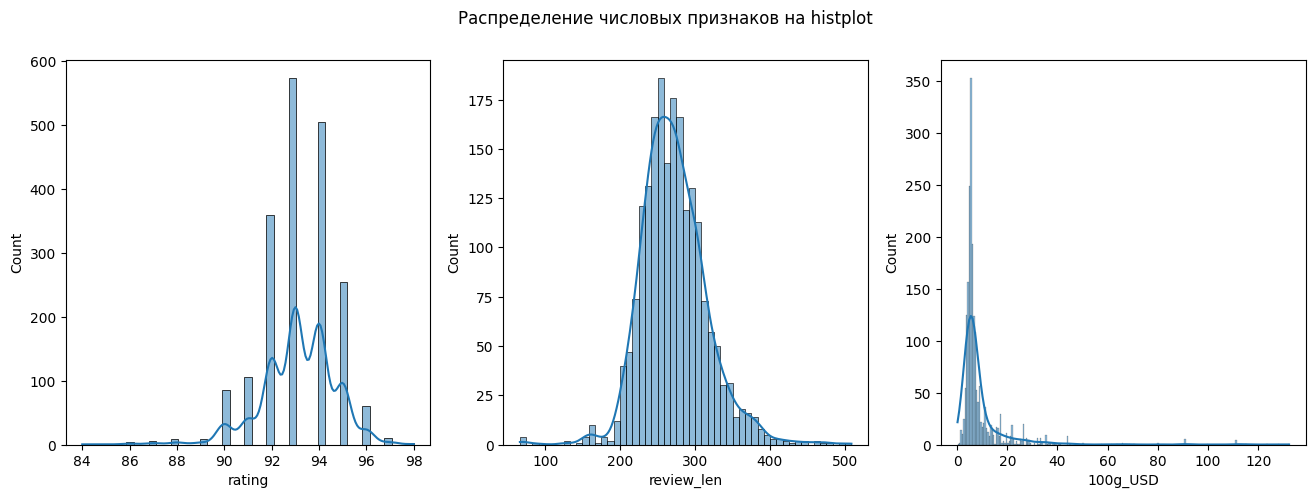

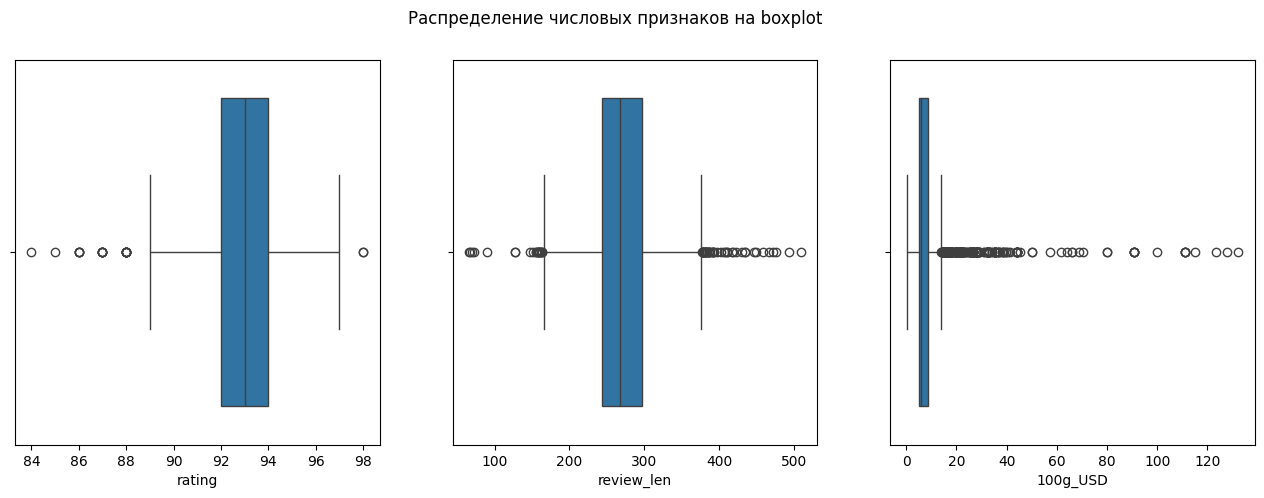

In [18]:
numeric_cols = ["rating", "review_len", "100g_USD"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Распределение числовых признаков на histplot")

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    sns.histplot(
        data=coffee_df,
        x=col,
        ax=ax,
        kde=True,
    )
    
    mean = coffee_df[col].mean()
    std = coffee_df[col].std()
    skew = coffee_df[col].skew()
    kurt = coffee_df[col].kurt()
    print(
        f"Статистика для {col}:\n"
        f"Среднее: {mean:.2f}\n"
        f"Стандартное отклонение: {std:.2f}\n"
        f"Скос: {skew:.2f}\n"
        f"Смещение: {kurt:.2f}\n"
    )
    
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Распределение числовых признаков на boxplot")

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    sns.boxplot(
        data=coffee_df,
        x=col,
        ax=ax,
    )

**Вывод:**  
- `rating`: высокое среднее, низкая дисперсия, распределение скошено влево, островершинное
- `review_len`: умеренная дисперсия, распределение сколено вправо, островершинное
- `100g_USD`: стандартное отклонение больше среднего (высокий разброс цен), распределение сильно скошено вправо, очень высокая островершинность (выбросы, тяжелый хвост)

### Анализ распределения категориальных признаков `name`, `roaster`, `roast` и нормализованных признаков стран

In [19]:
categories_col = ["name", "roaster", "roast", "origin_1", "origin_2"]

coffee_df[categories_col].describe()

,name,roaster,roast,origin_1,origin_2
count,1988,1988,1988,1988,1988
unique,1810,408,5,36,36
top,Ethiopia Kayon Mountain,JBC Coffee Roasters,Medium-Light,Ethiopia,Ethiopia
freq,6,149,1426,554,555


In [20]:
# В моем понимании, признак "name" в данном случае ничем не отличается от "uid",
# поэтому эту колонку исключаю
coffee_df.drop("name", axis=1, inplace=True)

In [21]:
def trancate_categories_by_freq(
    df: pd.DataFrame,
    col: str,
    labels: list[str],
    bins: list[int | float],
) -> pd.Series:
    """Разделение категорий по частоте на заданные группы."""
    counts = df[col].value_counts()
    tranc_cat = pd.cut(
        x=counts,
        bins=bins,
        labels=labels,
        right=False,
    )
    return df[col].map(tranc_cat)

In [22]:
roaster_labels = ["other", "medium", "high"]
roaster_bins = [0, 10, 100, np.inf]

coffee_df["roaster"] = trancate_categories_by_freq(
    df=coffee_df,
    col="roaster",
    labels=roaster_labels,
    bins=roaster_bins,
)

display(coffee_df["roaster"].value_counts())

roaster
other     804
medium    777
high      407
Name: count, dtype: int64

In [23]:
origins_labels = ["other", "low", "medium", "high", "very_high"]
origins_bins = [0, 10, 75, 125, 200, np.inf]
origins_col = ["origin_1", "origin_2"]

for col in origins_col:
    coffee_df[col] = trancate_categories_by_freq(
        df=coffee_df,
        col=col,
        labels=origins_labels,
        bins=origins_bins,
    )
    display(coffee_df[col].value_counts())


origin_1
very_high    797
low          608
high         342
medium       206
other         35
Name: count, dtype: int64

origin_2
very_high    795
low          492
high         361
medium       299
other         41
Name: count, dtype: int64

In [24]:
coffee_df.head(3)

,roaster,roast,loc_country,origin_1,origin_2,100g_USD,rating,review_date,review_len
0,other,Medium-Light,China,low,very_high,14.32,95.0,2017-11-01,387
1,medium,Medium-Light,United States,very_high,very_high,4.70,92.0,2017-11-01,305
2,other,Medium-Light,United States,very_high,very_high,4.19,92.0,2017-11-01,264


**Вывод:**  
Все категориальные признаки, кроме `roast`, имеют большое количество уникальных значений, что не позволят просто сделать `get_dummies` или `one-hot encoding`, тем самым сделав сильно разреженную матрицу, поэтому требуется разделить их по группам на основе частоты упоминаний. Границы выбраны эмпирически на основе анализа распределения, где `10` - порог самых редких событий.

## Отбор и преобразование признаков


### Кодирование категориальных признаков

In [25]:
categories_col = ["roaster", "roast", "loc_country", "origin_1", "origin_2"]

coffee_df[categories_col].describe()

,roaster,roast,loc_country,origin_1,origin_2
count,1988,1988,1988,1988,1988
unique,3,5,14,5,5
top,other,Medium-Light,United States,very_high,very_high
freq,804,1426,1330,797,795


In [26]:
coffee_df = pd.get_dummies(
    coffee_df,
    categories_col,
)

print(coffee_df.shape)
display(coffee_df.head(3))

(1988, 36)


,100g_USD,rating,review_date,review_len,roaster_other,roaster_medium,roaster_high,roast_Dark,roast_Light,roast_Medium,...,origin_1_other,origin_1_low,origin_1_medium,origin_1_high,origin_1_very_high,origin_2_other,origin_2_low,origin_2_medium,origin_2_high,origin_2_very_high
0,14.32,95.0,2017-11-01,387,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1,4.70,92.0,2017-11-01,305,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,4.19,92.0,2017-11-01,264,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


**Вывод:**  
Метод `get_dummies` был выбран потому, что количество уникальных категорий в признаках `roaster | 3`, `roast | 5`, `loc_country | 14`, `origin_1 | 5`, `origin_2 | 5` достаточно низкое. Это позволяет избежать проблемы проклятия размерности при one-hot кодировании.

### Масштабирование числовых признаков

In [27]:
nums_col = ["rating", "review_len"]
display(coffee_df[nums_col].describe())

target = "100g_USD"
display(coffee_df[target].describe())

,rating,review_len
count,1988.000000,1988.000000
mean,93.130785,272.208249
std,1.540919,44.475378
min,84.000000,66.000000
25%,92.000000,244.000000
50%,93.000000,268.000000
75%,94.000000,297.000000
max,98.000000,509.000000


count    1988.000000
mean        9.214437
std        11.481039
min         0.170000
25%         4.930000
50%         5.860000
75%         8.485000
max       132.280000
Name: 100g_USD, dtype: float64

In [28]:
scaler = preprocessing.StandardScaler()
coffee_df[nums_col] = scaler.fit_transform(coffee_df[nums_col])
display(coffee_df[nums_col].head(3))


coffee_df[target] = np.log1p(coffee_df[target])
display(coffee_df[target].head(3))

,rating,review_len
0,1.213357,2.581667
1,-0.734022,0.737487
2,-0.734022,-0.184604


0    2.729159
1    1.740466
2    1.646734
Name: 100g_USD, dtype: float64

**Вывод:**  
Стандартизация признаков `rating` и `review_len` выполнена с помощью `StandardScaler`, чтобы привести их к единому масштабу. Логарифмирование применено к целевой переменной `100g_USD` для устранения сильной правосторонней асимметрии и сглаживания влияния выбросов.

### Разделение данных на обучающую и тестовую

In [29]:
X = coffee_df.drop(columns=["review_date", "100g_USD"])
y = coffee_df[target]

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

(1988, 34)
(1988,)


### Отбор признаков

In [30]:
kbest_selector = feature_selection.SelectKBest(
    feature_selection.f_regression,
    k=30,
)

X_train_kbest = kbest_selector.fit_transform(X_train, y_train)

selected_features = X_train.columns[kbest_selector.get_support()]
print("Выбранные признаки:", selected_features.to_list())

Выбранные признаки: ['rating', 'review_len', 'roaster_other', 'roaster_medium', 'roast_Dark', 'roast_Light', 'roast_Medium', 'roast_Medium-Light', 'loc_country_Australia', 'loc_country_Belgium', 'loc_country_Canada', 'loc_country_China', 'loc_country_England', 'loc_country_Guatemala', 'loc_country_Honduras', 'loc_country_Japan', 'loc_country_Malaysia', 'loc_country_Mexico', 'loc_country_Peru', 'loc_country_United States', 'origin_1_other', 'origin_1_low', 'origin_1_medium', 'origin_1_high', 'origin_1_very_high', 'origin_2_other', 'origin_2_low', 'origin_2_medium', 'origin_2_high', 'origin_2_very_high']


In [31]:
# обратное преобразование из log-шкалы
y_train_original = np.expm1(y_train)
y_test_original = np.expm1(y_test)

# Константное предсказание - среднее по train
y_pred = np.full_like(y_test_original, fill_value=y_train_original.mean(), dtype=float)

# Метрики
mse = metrics.mean_squared_error(y_test_original, y_pred)
mape = metrics.mean_absolute_percentage_error(y_test_original, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f}")

MSE: 176.6692
MAPE: 0.6938


### Анализ временного ряда

In [32]:
coffee_df["review_date"].info()

<class 'pandas.core.series.Series'>
Index: 1988 entries, 0 to 1995
Series name: review_date
Non-Null Count  Dtype         
--------------  -----         
1988 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 31.1 KB


Text(0, 0.5, 'Средняя цена')

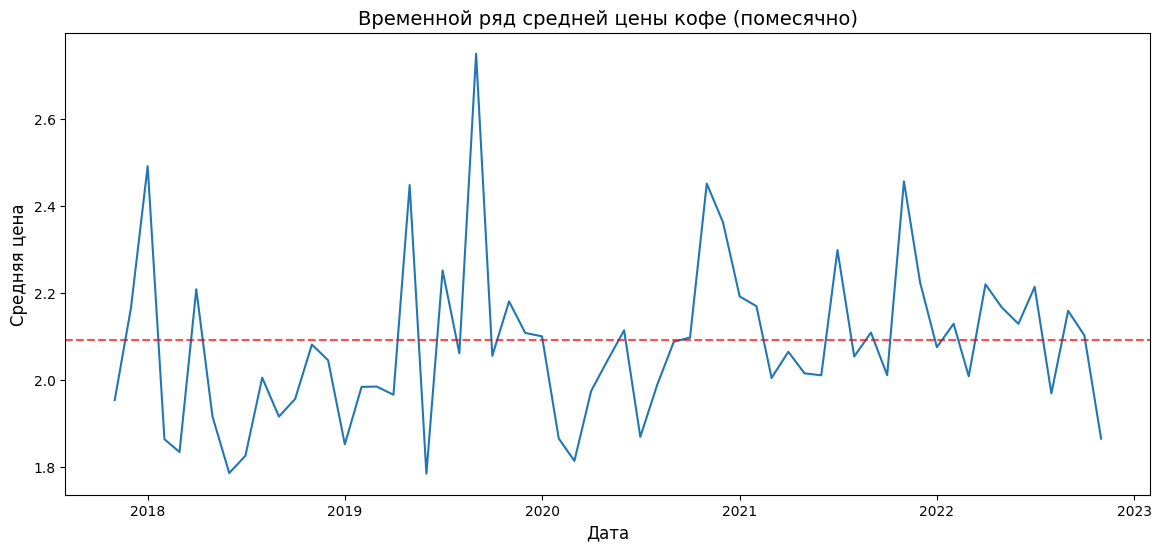

In [33]:
coffee_df["year_month"] = coffee_df["review_date"].dt.to_period("M")
monthly_prices = coffee_df.groupby("year_month")["100g_USD"].mean()
monthly_prices.index = monthly_prices.index.to_timestamp()
target_mean = coffee_df["100g_USD"].mean()

plt.figure(figsize=(14, 6))

sns.lineplot(
    x=monthly_prices.index,
    y=monthly_prices.values,
)

plt.axhline(
    y=target_mean,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"Среднее за период: {target_mean:.2f}"
)

plt.title("Временной ряд средней цены кофе (помесячно)", fontsize=14)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Средняя цена", fontsize=12)

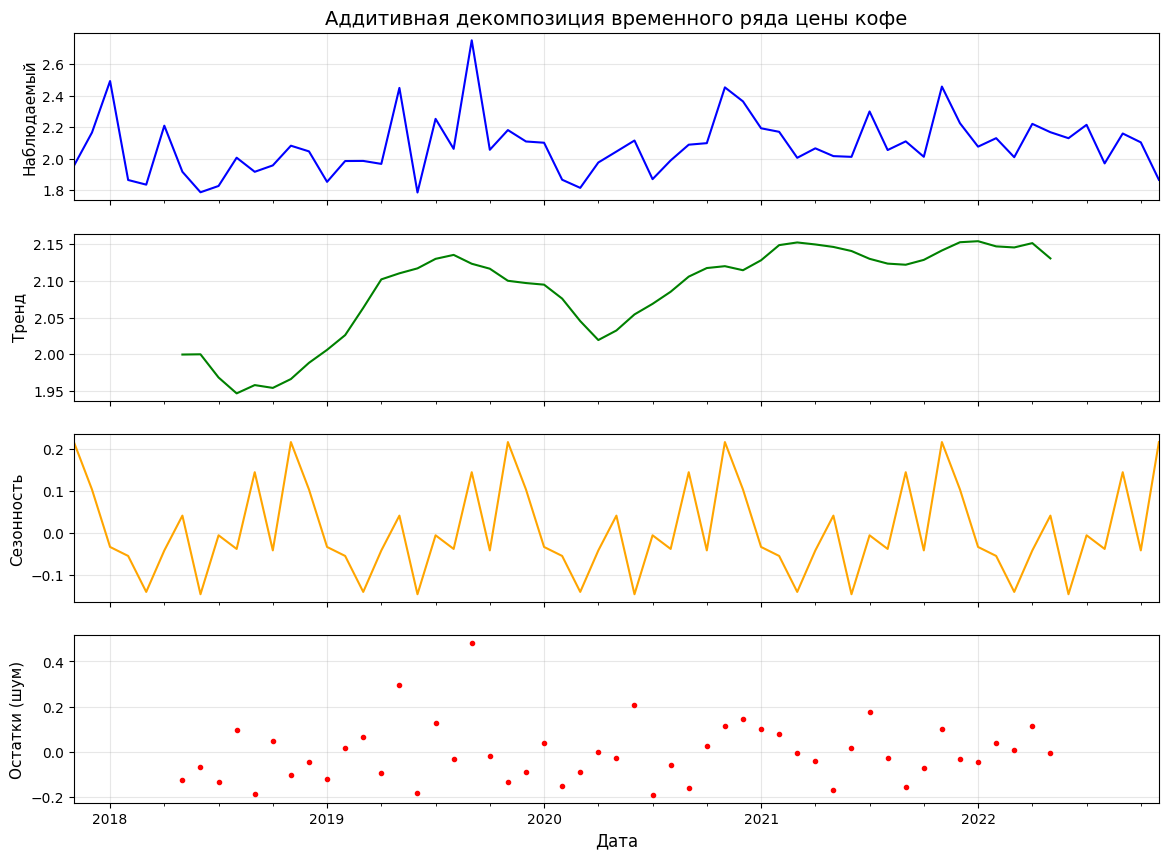

In [34]:
decomposition = seasonal_decompose(monthly_prices, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

decomposition.observed.plot(ax=axes[0], color="blue")
axes[0].set_ylabel("Наблюдаемый", fontsize=11)
axes[0].set_title("Аддитивная декомпозиция временного ряда цены кофе", fontsize=14)
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], color="green")
axes[1].set_ylabel("Тренд", fontsize=11)
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], color="orange")
axes[2].set_ylabel("Сезонность", fontsize=11)
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], color="red", marker="o", linestyle="", markersize=3)
axes[3].set_ylabel("Остатки (шум)", fontsize=11)
axes[3].set_xlabel("Дата", fontsize=12)
axes[3].grid(True, alpha=0.3)

**Вывод:**  
- присутствует тренд на увеличение средней цены кофе со временем
- так же можно наблюдать существенно выраженную сезонность
- высокая доля шума